In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import shutil, zipfile, os

shutil.copy('/content/drive/MyDrive/geopotential_500.zip', 'geopotential_500.zip')

os.makedirs("geopotential_500", exist_ok=True)

with zipfile.ZipFile("geopotential_500.zip", 'r') as zip_ref:
    zip_ref.extractall("geopotential_500")

print("Extracted successfully!")
print(os.listdir("geopotential_500"))

Extracted successfully!
['geopotential_500']


In [5]:
os.makedirs("geopotential_500", exist_ok=True)
with zipfile.ZipFile("geopotential_500.zip", 'r') as zip_ref:
    zip_ref.extractall("geopotential_500")

print("Outer extracted:", os.listdir("geopotential_500"))

inner_zip = "geopotential_500/geopotential_500/geopotential_500_5.625deg.zip"
os.makedirs("geopotential_500_data", exist_ok=True)
with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
    zip_ref.extractall("geopotential_500_data")

print("Done")
print(os.listdir("geopotential_500_data"))

Outer extracted: ['geopotential_500']
Done
['geopotential_500hPa_2015_5.625deg.nc', 'geopotential_500hPa_2001_5.625deg.nc', 'geopotential_500hPa_1980_5.625deg.nc', 'geopotential_500hPa_2016_5.625deg.nc', 'geopotential_500hPa_1994_5.625deg.nc', 'geopotential_500hPa_1982_5.625deg.nc', 'geopotential_500hPa_2012_5.625deg.nc', 'geopotential_500hPa_2007_5.625deg.nc', 'geopotential_500hPa_1996_5.625deg.nc', 'geopotential_500hPa_1992_5.625deg.nc', 'geopotential_500hPa_2013_5.625deg.nc', 'geopotential_500hPa_2000_5.625deg.nc', 'geopotential_500hPa_1981_5.625deg.nc', 'geopotential_500hPa_2004_5.625deg.nc', 'geopotential_500hPa_1998_5.625deg.nc', 'geopotential_500hPa_2017_5.625deg.nc', 'geopotential_500hPa_2002_5.625deg.nc', 'geopotential_500hPa_1987_5.625deg.nc', 'geopotential_500hPa_1999_5.625deg.nc', 'geopotential_500hPa_2006_5.625deg.nc', 'geopotential_500hPa_1990_5.625deg.nc', 'geopotential_500hPa_1979_5.625deg.nc', 'geopotential_500hPa_1989_5.625deg.nc', 'geopotential_500hPa_1995_5.625deg.n

In [7]:
!pip install -q xarray netCDF4 h5netcdf matplotlib scikit-learn tensorflow

In [8]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import zipfile
import os

In [9]:
extract_path = "/content/geopotential_500_data"

files = sorted([
    os.path.join(extract_path, f)
    for f in os.listdir(extract_path)
    if f.endswith(".nc")
])

print(f"Total files: {len(files)}")

Total files: 40


In [10]:
datasets = [xr.open_dataset(f) for f in files]
ds = xr.concat(datasets, dim="time")
print(ds)

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 350640, lat: 32, lon: 64)
Coordinates:
  * time     (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31T23:00:00
  * lat      (lat) float64 256B -87.19 -81.56 -75.94 ... 75.94 81.56 87.19
  * lon      (lon) float64 512B 0.0 5.625 11.25 16.88 ... 343.1 348.8 354.4
    level    int32 4B 500
Data variables:
    z        (time, lat, lon) float32 3GB 5.156e+04 5.158e+04 ... 4.873e+04
Attributes:
    Conventions:  CF-1.6
    history:      2019-11-10 20:33:23 GMT by grib_to_netcdf-2.14.0: /opt/ecmw...


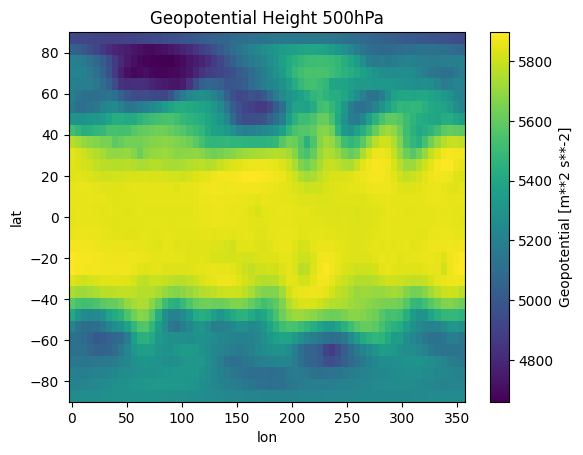

Shape: (350640, 32, 64)
Dims : ('time', 'lat', 'lon')


In [11]:
z = ds['z']
z_height = z / 9.81

z_height.isel(time=0).plot()
plt.title("Geopotential Height 500hPa")
plt.show()

print("Shape:", z_height.shape)
print("Dims :", z_height.dims)

In [12]:
datasets = [xr.open_dataset(f) for f in files]

In [13]:
z = ds['z']

In [14]:
z_height = z / 9.81

In [15]:
print(z_height.shape)
print(z_height.dims)

(350640, 32, 64)
('time', 'lat', 'lon')


In [16]:
import numpy as np
from sklearn.preprocessing import StandardScaler

SUBSET = 5000

z_np = z_height.values[:SUBSET]
n_time, n_lat, n_lon = z_np.shape
print("Subset shape:", z_np.shape)

z_flat = z_np.reshape(n_time, -1).astype(np.float32)

scaler = StandardScaler()
z_scaled = scaler.fit_transform(z_flat)

z_scaled = z_scaled.reshape(n_time, n_lat, n_lon)

print("Scaled shape:", z_scaled.shape)
print("Mean (~0):", round(z_scaled.mean(), 4))
print("Std  (~1):", round(z_scaled.std(), 4))

Subset shape: (5000, 32, 64)
Scaled shape: (5000, 32, 64)
Mean (~0): 0.0
Std  (~1): 1.0


Original (fine) shape: (32, 64)
Coarse shape: (32, 64)


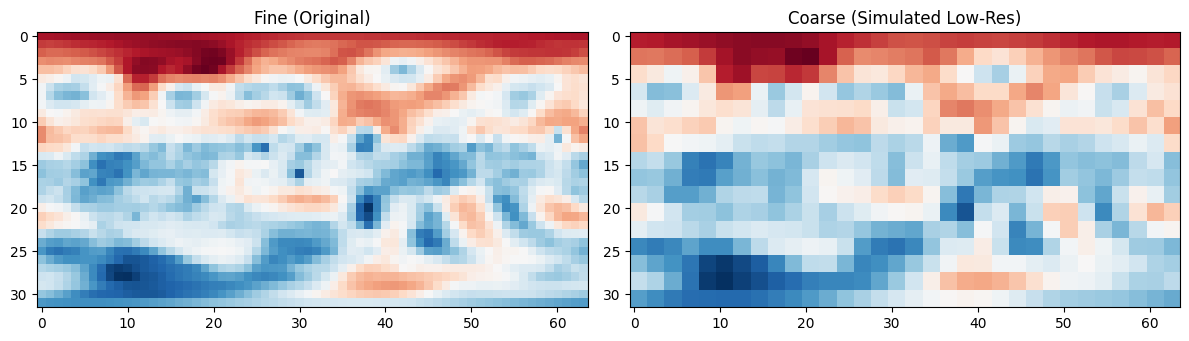

In [17]:
def make_coarse(frame, factor=2):

    h, w = frame.shape
    h_new, w_new = h // factor, w // factor

    coarse_small = frame[:h_new*factor, :w_new*factor]\
                       .reshape(h_new, factor, w_new, factor).mean(axis=(1,3))

    coarse_up = np.repeat(np.repeat(coarse_small, factor, axis=0), factor, axis=1)
    return coarse_up

sample = z_scaled[0]
coarse_sample = make_coarse(sample, factor=2)
print("Original (fine) shape:", sample.shape)
print("Coarse shape:", coarse_sample.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(sample, cmap='RdBu_r')
axes[0].set_title('Fine (Original)')
axes[1].imshow(coarse_sample, cmap='RdBu_r')
axes[1].set_title('Coarse (Simulated Low-Res)')
plt.tight_layout()
plt.show()

In [18]:
SUBSET = 5000

X = np.array([make_coarse(z_scaled[t], factor=2) for t in range(SUBSET)])
Y = z_scaled[:SUBSET]

print("X (coarse input) shape:", X.shape)
print("Y (fine target) shape: ", Y.shape)

X (coarse input) shape: (5000, 32, 64)
Y (fine target) shape:  (5000, 32, 64)


X (coarse input) shape: (5000, 32, 64)
Y (fine target)  shape: (5000, 32, 64)


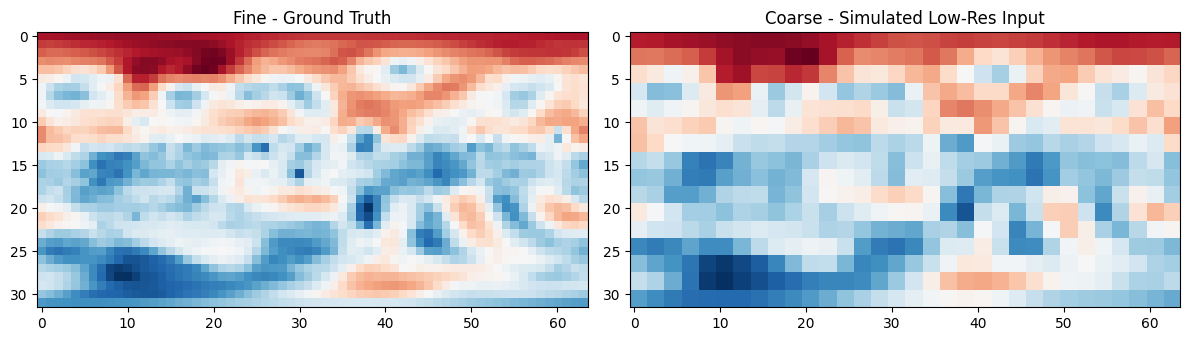

In [19]:
def make_coarse(frame, factor=2):
    """Downsample then upsample to simulate low-resolution input"""
    h, w = frame.shape
    h_new, w_new = h // factor, w // factor

    coarse_small = frame[:h_new*factor, :w_new*factor]\
                       .reshape(h_new, factor, w_new, factor).mean(axis=(1,3))

    coarse_up = np.repeat(np.repeat(coarse_small, factor, axis=0), factor, axis=1)
    return coarse_up

X = np.array([make_coarse(z_scaled[t], factor=2) for t in range(SUBSET)])
Y = z_scaled.copy()

print("X (coarse input) shape:", X.shape)
print("Y (fine target)  shape:", Y.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(Y[0], cmap='RdBu_r')
axes[0].set_title('Fine - Ground Truth')
axes[1].imshow(X[0], cmap='RdBu_r')
axes[1].set_title('Coarse - Simulated Low-Res Input')
plt.tight_layout()
plt.show()

In [20]:
SEQ_LEN = 10

def create_sequences(X, Y, seq_len):
    Xs, Ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i+seq_len])
        Ys.append(Y[i + seq_len])
    return np.array(Xs, dtype=np.float32), np.array(Ys, dtype=np.float32)

X_seq, Y_seq = create_sequences(X, Y, SEQ_LEN)
print("X_seq shape:", X_seq.shape)
print("Y_seq shape:", Y_seq.shape)

X_seq shape: (4990, 10, 32, 64)
Y_seq shape: (4990, 32, 64)


In [21]:
n = len(X_seq)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, Y_train = X_seq[:train_end],       Y_seq[:train_end]
X_val,   Y_val   = X_seq[train_end:val_end], Y_seq[train_end:val_end]
X_test,  Y_test  = X_seq[val_end:],          Y_seq[val_end:]

print(f"Train samples : {len(X_train)}")
print(f"Val   samples : {len(X_val)}")
print(f"Test  samples : {len(X_test)}")

Train samples : 3493
Val   samples : 748
Test  samples : 749


In [22]:
n_lat, n_lon = 32, 64
n_features = n_lat * n_lon

X_train_flat = X_train.reshape(len(X_train), SEQ_LEN, n_features)
X_val_flat   = X_val.reshape(len(X_val),   SEQ_LEN, n_features)
X_test_flat  = X_test.reshape(len(X_test),  SEQ_LEN, n_features)

Y_train_flat = Y_train.reshape(len(Y_train), n_features)
Y_val_flat   = Y_val.reshape(len(Y_val),   n_features)
Y_test_flat  = Y_test.reshape(len(Y_test),  n_features)

print("X_train_flat:", X_train_flat.shape)
print("Y_train_flat:", Y_train_flat.shape)

X_train_flat: (3493, 10, 2048)
Y_train_flat: (3493, 2048)


In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_lstm = Sequential([
    LSTM(128, input_shape=(SEQ_LEN, n_features), return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(n_features)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │     1,114,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │       133,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297,152 (4.95 MB)

 Trainable params: 1,297,152 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_lstm.keras', save_best_only=True, verbose=1)

history = model_lstm.fit(
    X_train_flat, Y_train_flat,
    validation_data=(X_val_flat, Y_val_flat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.6623
Epoch 1: val_loss improved from None to 0.70906, saving model to best_lstm.keras

Epoch 1: finished saving model to best_lstm.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - loss: 0.5530 - val_loss: 0.7091
Epoch 2/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.3998
Epoch 2: val_loss did not improve from 0.70906
110/110 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - loss: 0.3766 - val_loss: 0.7216
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.3197
Epoch 3: val_loss did not improve from 0.70906
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 0.3087 - val_loss: 0.7822
Epoch 4/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.2767
Epoch 4: val_loss did not improve from 0.70906
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 0.2688 - val_loss: 0.8545
Epoch 5/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.2434
Epoch 5: val_loss did not improve from 0.70906
110/110 ━━━━━━━━━━━━━━━━━━━━ 1

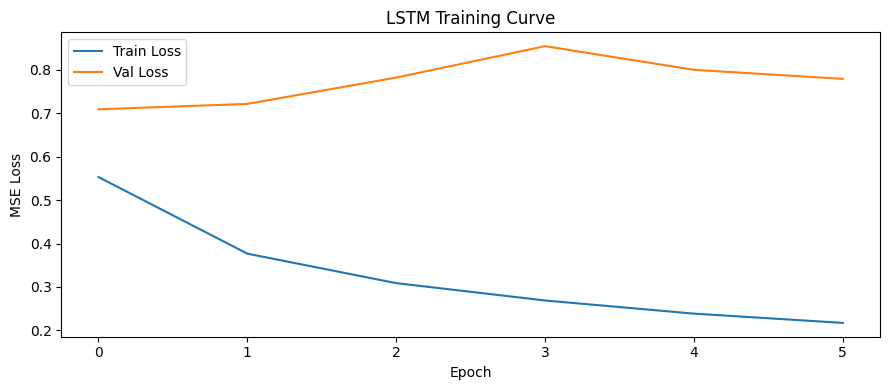

In [25]:
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step
LSTM Test RMSE: 1.0228


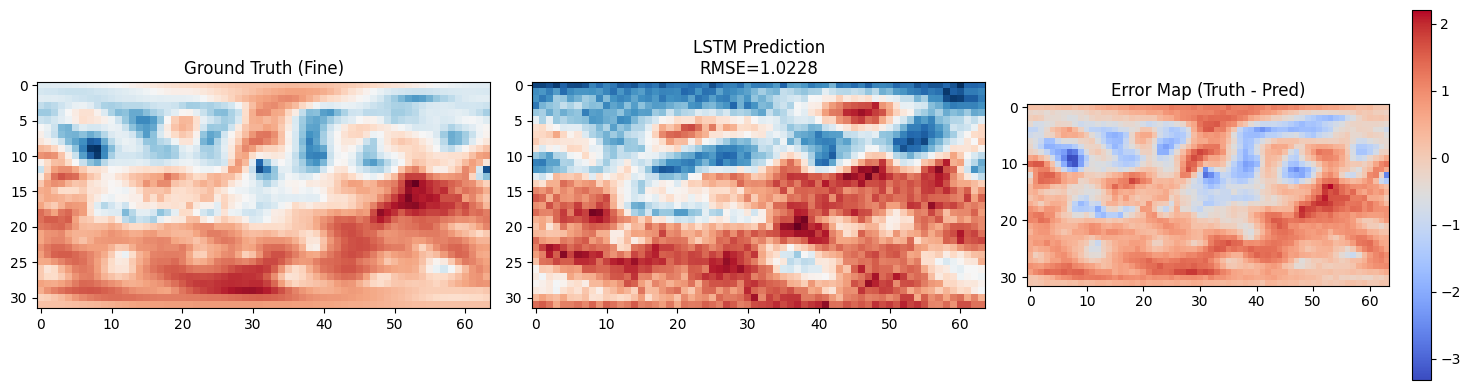

In [26]:
from sklearn.metrics import mean_squared_error

lstm_preds = model_lstm.predict(X_test_flat)

rmse = np.sqrt(mean_squared_error(Y_test_flat, lstm_preds))
print(f"LSTM Test RMSE: {rmse:.4f}")

sample_idx = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(Y_test_flat[sample_idx].reshape(n_lat, n_lon), cmap='RdBu_r')
axes[0].set_title('Ground Truth (Fine)')

axes[1].imshow(lstm_preds[sample_idx].reshape(n_lat, n_lon), cmap='RdBu_r')
axes[1].set_title(f'LSTM Prediction\nRMSE={rmse:.4f}')

error = Y_test_flat[sample_idx] - lstm_preds[sample_idx]
im = axes[2].imshow(error.reshape(n_lat, n_lon), cmap='coolwarm')
axes[2].set_title('Error Map (Truth - Pred)')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

In [27]:


from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization,
                                     MultiHeadAttention, GlobalAveragePooling1D)

def build_transformer(seq_len, n_features, d_model=128, num_heads=4,
                       ff_dim=256, num_layers=2, dropout=0.1):
    inputs = Input(shape=(seq_len, n_features))
    x = Dense(d_model)(inputs)

    for _ in range(num_layers):
        attn_out = MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)(x, x)
        attn_out = Dropout(dropout)(attn_out)
        x = LayerNormalization(epsilon=1e-6)(x + attn_out)
        ff_out = Dense(ff_dim, activation='relu')(x)
        ff_out = Dense(d_model)(ff_out)
        ff_out = Dropout(dropout)(ff_out)
        x = LayerNormalization(epsilon=1e-6)(x + ff_out)

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(n_features)(x)
    model = Model(inputs, outputs)
    return model

model_transformer = build_transformer(SEQ_LEN, n_features)
model_transformer.compile(optimizer='adam', loss='mse')
print(" Transformer model built successfully")
model_transformer.summary()

 Transformer model built successfully


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10, 2048)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10, 128)   │    262,272 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ dense_1[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 10, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 128)   │          0 │ dense_1[0][0],    │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10, 128)   │     32,896 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 10, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 10, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 10, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10, 128)   │     32,896 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 10, 128)   │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 10, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_3[0][0]     

 Total params: 791,424 (3.02 MB)

 Trainable params: 791,424 (3.02 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_t = EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
checkpoint_t = ModelCheckpoint('best_transformer.keras', save_best_only=True, verbose=1)

history_t = model_transformer.fit(
    X_train_flat, Y_train_flat,
    validation_data=(X_val_flat, Y_val_flat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_t, checkpoint_t],
    verbose=1
)
print(" Transformer training complete")

Epoch 1/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.5321
Epoch 1: val_loss improved from None to 0.57350, saving model to best_transformer.keras

Epoch 1: finished saving model to best_transformer.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 170ms/step - loss: 0.3783 - val_loss: 0.5735
Epoch 2/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.1927
Epoch 2: val_loss improved from 0.57350 to 0.55098, saving model to best_transformer.keras

Epoch 2: finished saving model to best_transformer.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step - loss: 0.1718 - val_loss: 0.5510
Epoch 3/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 0.1134
Epoch 3: val_loss improved from 0.55098 to 0.54839, saving model to best_transformer.keras

Epoch 3: finished saving model to best_transformer.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - loss: 0.0993 - val_loss: 0.5484
Epoch 4/30
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.0713
Epoch 4: val_loss improved from 0.54839 to 0.5

In [29]:
from sklearn.metrics import mean_squared_error

transformer_preds = model_transformer.predict(X_test_flat)
rmse_transformer = np.sqrt(mean_squared_error(Y_test_flat, transformer_preds))

print(f"LSTM        Test RMSE : {rmse:.4f}")
print(f"Transformer Test RMSE : {rmse_transformer:.4f}")
print(" transformer_preds is now ready")

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
LSTM        Test RMSE : 1.0228
Transformer Test RMSE : 0.8315
 transformer_preds is now ready


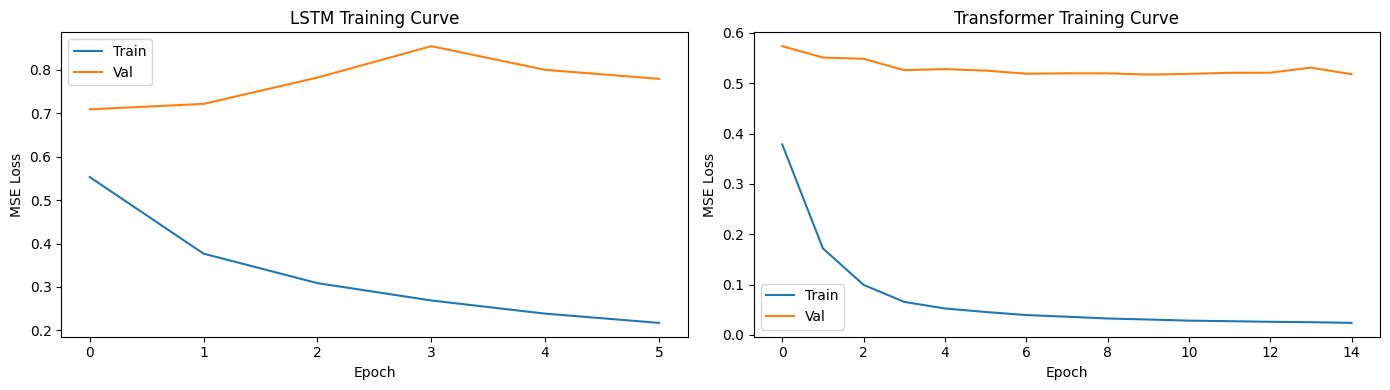

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('LSTM Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(history_t.history['loss'],     label='Train')
axes[1].plot(history_t.history['val_loss'], label='Val')
axes[1].set_title('Transformer Training Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

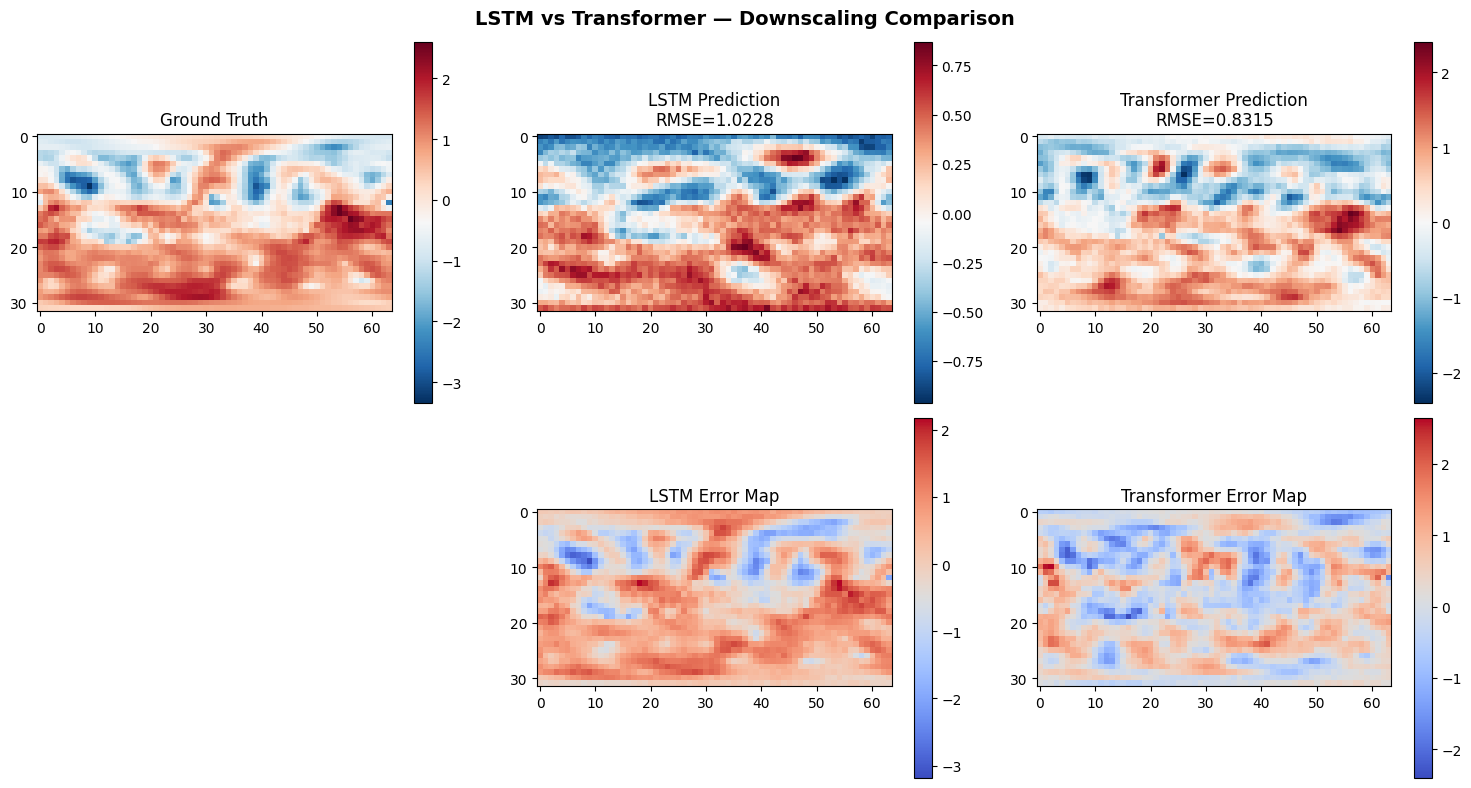

In [31]:
sample_idx = 10

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

im0 = axes[0,0].imshow(Y_test_flat[sample_idx].reshape(n_lat, n_lon), cmap='RdBu_r')
axes[0,0].set_title('Ground Truth')
plt.colorbar(im0, ax=axes[0,0])

im1 = axes[0,1].imshow(lstm_preds[sample_idx].reshape(n_lat, n_lon), cmap='RdBu_r')
axes[0,1].set_title(f'LSTM Prediction\nRMSE={rmse:.4f}')
plt.colorbar(im1, ax=axes[0,1])

im2 = axes[0,2].imshow(transformer_preds[sample_idx].reshape(n_lat, n_lon), cmap='RdBu_r')
axes[0,2].set_title(f'Transformer Prediction\nRMSE={rmse_transformer:.4f}')
plt.colorbar(im2, ax=axes[0,2])

axes[1,0].axis('off')

err_lstm = (Y_test_flat[sample_idx] - lstm_preds[sample_idx]).reshape(n_lat, n_lon)
im4 = axes[1,1].imshow(err_lstm, cmap='coolwarm')
axes[1,1].set_title('LSTM Error Map')
plt.colorbar(im4, ax=axes[1,1])

err_trans = (Y_test_flat[sample_idx] - transformer_preds[sample_idx]).reshape(n_lat, n_lon)
im5 = axes[1,2].imshow(err_trans, cmap='coolwarm')
axes[1,2].set_title('Transformer Error Map')
plt.colorbar(im5, ax=axes[1,2])

plt.suptitle('LSTM vs Transformer — Downscaling Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

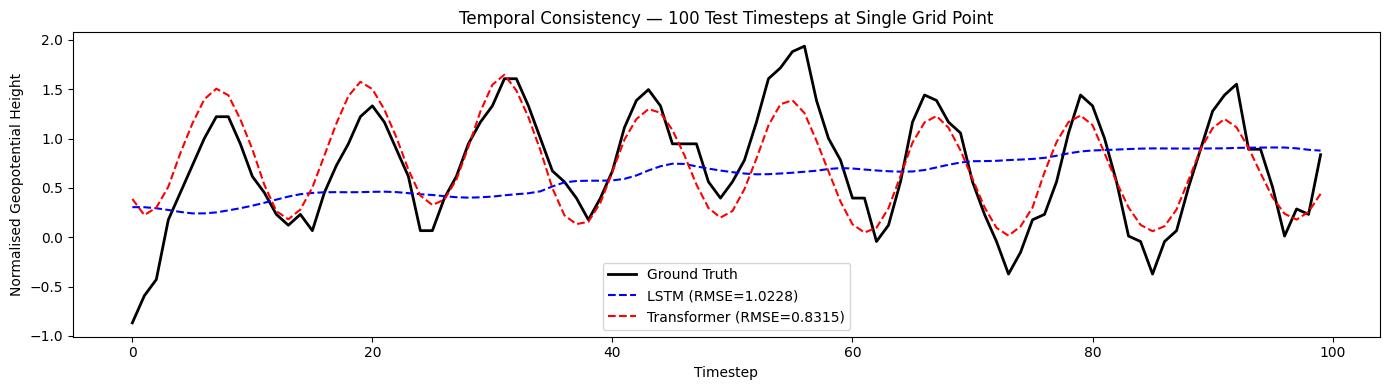

In [32]:
lat_idx, lon_idx = 16, 32

truth_series = Y_test_flat[:, lat_idx * n_lon + lon_idx]
lstm_series  = lstm_preds[:,  lat_idx * n_lon + lon_idx]
trans_series = transformer_preds[:, lat_idx * n_lon + lon_idx]

plt.figure(figsize=(14, 4))
plt.plot(truth_series[:100], label='Ground Truth', color='black', linewidth=2)
plt.plot(lstm_series[:100],  label=f'LSTM (RMSE={rmse:.4f})', color='blue', linestyle='--')
plt.plot(trans_series[:100], label=f'Transformer (RMSE={rmse_transformer:.4f})', color='red', linestyle='--')
plt.xlabel('Timestep')
plt.ylabel('Normalised Geopotential Height')
plt.title('Temporal Consistency — 100 Test Timesteps at Single Grid Point')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
import pandas as pd

summary = pd.DataFrame({
    'Model':         ['LSTM', 'Transformer'],
    'Test RMSE':     [round(rmse, 4), round(rmse_transformer, 4)],
    'Parameters':    [model_lstm.count_params(), model_transformer.count_params()],
    'Winner':        ['', ' Better RMSE']
})

print("=" * 55)
print("         FINAL PROJECT RESULTS SUMMARY")
print("=" * 55)
print(summary.to_string(index=False))
print("=" * 55)
print(f"\nConclusion: Transformer outperforms LSTM by "
      f"{((rmse - rmse_transformer)/rmse*100):.1f}% on climate downscaling.")

         FINAL PROJECT RESULTS SUMMARY
      Model  Test RMSE  Parameters       Winner
       LSTM     1.0228     1297152             
Transformer     0.8315      791424  Better RMSE

Conclusion: Transformer outperforms LSTM by 18.7% on climate downscaling.


In [34]:
persistence_preds = X_test_flat[:, -1, :]
rmse_persistence = np.sqrt(mean_squared_error(Y_test_flat, persistence_preds))

print("=" * 45)
print("       COMPLETE RESULTS WITH BASELINE")
print("=" * 45)
print(f"  Persistence Baseline RMSE : {rmse_persistence:.4f}")
print(f"  LSTM             RMSE     : {rmse:.4f}")
print(f"  Transformer      RMSE     : {rmse_transformer:.4f}")
print("=" * 45)
print(f"  LSTM improvement over baseline      : {((rmse_persistence - rmse)/rmse_persistence*100):.1f}%")
print(f"  Transformer improvement over baseline: {((rmse_persistence - rmse_transformer)/rmse_persistence*100):.1f}%")

       COMPLETE RESULTS WITH BASELINE
  Persistence Baseline RMSE : 0.3276
  LSTM             RMSE     : 1.0228
  Transformer      RMSE     : 0.8315
  LSTM improvement over baseline      : -212.2%
  Transformer improvement over baseline: -153.8%


Temporal Stability (Std of RMSE over time):
  LSTM        std: 0.0907  — lower is more stable
  Transformer std: 0.0724  — lower is more stable


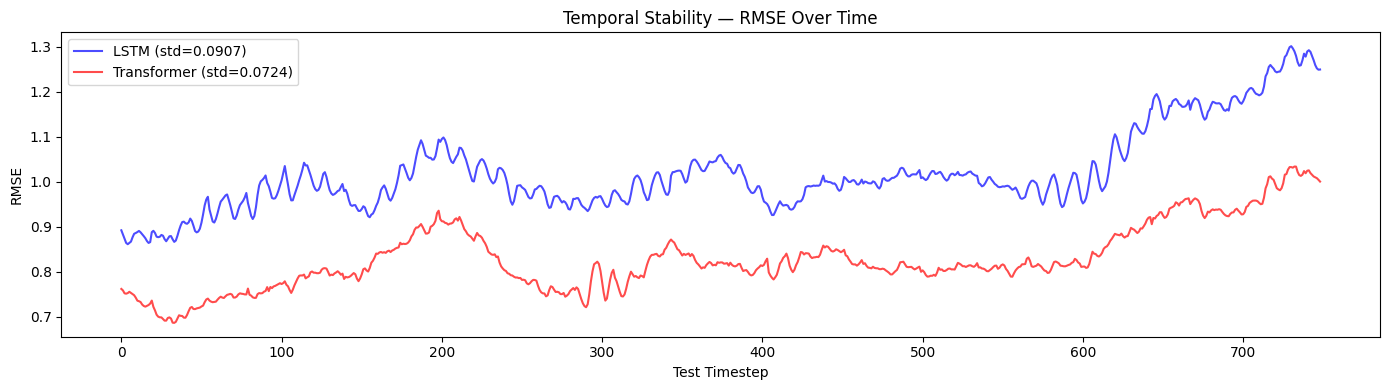

In [35]:
lstm_errors  = np.sqrt(((Y_test_flat - lstm_preds)**2).mean(axis=1))
trans_errors = np.sqrt(((Y_test_flat - transformer_preds)**2).mean(axis=1))

print("Temporal Stability (Std of RMSE over time):")
print(f"  LSTM        std: {lstm_errors.std():.4f}  — lower is more stable")
print(f"  Transformer std: {trans_errors.std():.4f}  — lower is more stable")

plt.figure(figsize=(14, 4))
plt.plot(lstm_errors,  label=f'LSTM (std={lstm_errors.std():.4f})',        color='blue', alpha=0.7)
plt.plot(trans_errors, label=f'Transformer (std={trans_errors.std():.4f})', color='red',  alpha=0.7)
plt.xlabel('Test Timestep')
plt.ylabel('RMSE')
plt.title('Temporal Stability — RMSE Over Time')
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
lstm_var  = lstm_preds.var(axis=0).mean()
trans_var = transformer_preds.var(axis=0).mean()
truth_var = Y_test_flat.var(axis=0).mean()

print("Prediction Uncertainty (Variance):")
print(f"  Ground Truth variance : {truth_var:.4f}")
print(f"  LSTM variance         : {lstm_var:.4f}")
print(f"  Transformer variance  : {trans_var:.4f}")

if abs(trans_var - truth_var) < abs(lstm_var - truth_var):
    print("\n   Transformer predictions are closer to true variance — less uncertainty")
else:
    print("\n   LSTM predictions are closer to true variance — less uncertainty")

Prediction Uncertainty (Variance):
  Ground Truth variance : 0.5867
  LSTM variance         : 0.0101
  Transformer variance  : 0.2944

   Transformer predictions are closer to true variance — less uncertainty


In [37]:
import pandas as pd

summary = pd.DataFrame({
    'Model':               ['Persistence Baseline', 'LSTM', 'Transformer'],
    'Test RMSE':           [round(rmse_persistence, 4), round(rmse, 4), round(rmse_transformer, 4)],
    'Temporal Stability':  ['N/A',
                            round(lstm_errors.std(), 4),
                            round(trans_errors.std(), 4)],
    'Pred Variance':       ['N/A', round(lstm_var, 4), round(trans_var, 4)],
    'vs Baseline':         ['—',
                            f"-{((rmse_persistence-rmse)/rmse_persistence*100):.1f}%",
                            f"-{((rmse_persistence-rmse_transformer)/rmse_persistence*100):.1f}%"]
})

print("=" * 75)
print("                  FINAL PROJECT RESULTS — ALL METRICS")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)


                  FINAL PROJECT RESULTS — ALL METRICS
               Model  Test RMSE Temporal Stability Pred Variance vs Baseline
Persistence Baseline     0.3276                N/A           N/A           —
                LSTM     1.0228             0.0907        0.0101    --212.2%
         Transformer     0.8315             0.0724        0.2944    --153.8%
